In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import pandas as pd

%config InlineBackend.figure_format = 'svg'
plt.style.use('seaborn-v0_8-whitegrid')
import torch
from transformers import AutoModelForCausalLM

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B",  # 3B fits easily, use 7B if you want
    torch_dtype=torch.float16,
    device_map="auto"  # CPU is fine, you're not doing inference
)
cfg = model.config
L = cfg.num_hidden_layers   # L
d = cfg.hidden_size         # d
d_ff = cfg.intermediate_size   # d_ff
h = cfg.num_attention_heads # h
GQA = cfg.num_key_value_heads # GQA heads (if different from h)
V = cfg.vocab_size          # |V|

print(f"L: {L}, d: {d}, d_ff: {d_ff}, h: {h}, GQA: {GQA}, V: {V}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

L: 36, d: 2048, d_ff: 11008, h: 16, GQA: 2, V: 151936


In [ ]:
layer_idx = 18
assert (layer_idx >= 0) and (layer_idx < L), f"layer_idx must be in [0, L-1]. In this case, L={L}, received layer_idx={layer_idx}"

# Pick a layer to inspect
layer = model.model.layers[18]  # layer 0..L-1

# Attention matrices
W_Q = layer.self_attn.q_proj.weight.data  # (d, d)
assert W_Q.shape == (d, d), f'W_Q.shape must be (d, d)=({d}, {d}), received {W_Q.shape}'
d_kv = (d // h) * GQA  # KV dimension with GQA
W_K = layer.self_attn.k_proj.weight.data
assert W_K.shape == (d_kv, d), f'W_K.shape must be (d_kv, d)=({d_kv}, {d}), received {W_K.shape}'
W_V = layer.self_attn.v_proj.weight.data
assert W_V.shape == (d_kv, d), f'W_V.shape must be (d_kv, d)=({d_kv}, {d}), received {W_V.shape}'
W_O = layer.self_attn.o_proj.weight.data
assert W_O.shape == (d, d), f'W_O.shape must be (d, d)=({d}, {d}), received {W_O.shape}'

# FFN matrices
W_gate = layer.mlp.gate_proj.weight.data  # (d_ff, d)
assert W_gate.shape == (d_ff, d), f'W_gate.shape must be (d_ff, d)=({d_ff}, {d}), received {W_gate.shape}'
W_up   = layer.mlp.up_proj.weight.data
assert W_up.shape == (d_ff, d), f'W_up.shape must be (d_ff, d)=({d_ff}, {d}), received {W_up.shape}'
W_down = layer.mlp.down_proj.weight.data
assert W_down.shape == (d, d_ff), f'W_down.shape must be (d, d_ff)=({d}, {d_ff}), received {W_down.shape}'

print(f"W_Q: {W_Q.shape}, W_gate: {W_gate.shape}")

W_Q: torch.Size([2048, 2048]), W_gate: torch.Size([11008, 2048])


W_Q_h: torch.Size([128, 2048]), W_K_h: torch.Size([128, 2048]), kernel: torch.Size([2048, 2048])

Layer 18, Head 0 (KV head 0)
  Kernel shape: torch.Size([2048, 2048])
  Asymmetry: ||A - A^T|| / ||A|| = 1.3514
  Complex eigenvalues: 116/2048 (5.7%)
  Top 128 eigenvalues capture 100.0% of spectral energy
  Effective rank (eigenvalue mag): 80.1
  Top 10 eigenvalues (real, imag, mag):
    0: real=+3.346994  imag=+0.000000  |λ|=3.346994
    1: real=+2.778572  imag=+0.000000  |λ|=2.778572
    2: real=+2.310925  imag=+0.000000  |λ|=2.310925
    3: real=+2.068550  imag=+0.000000  |λ|=2.068550
    4: real=+1.899170  imag=+0.000000  |λ|=1.899170
    5: real=+1.861921  imag=+0.237437  |λ|=1.876999
    6: real=+1.861921  imag=-0.237437  |λ|=1.876999
    7: real=+1.587069  imag=+0.530491  |λ|=1.673382
    8: real=+1.587069  imag=-0.530491  |λ|=1.673382
    9: real=+1.486888  imag=+0.128161  |λ|=1.492401


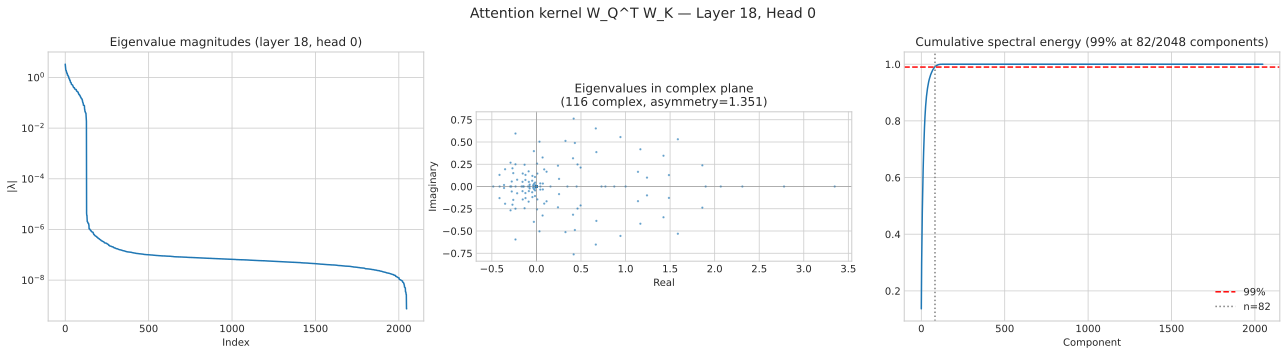

In [ ]:
d_head = d // h
n_kv_groups = h // GQA  # query heads per KV head

head_idx = 0
kv_head_idx = head_idx // n_kv_groups

W_Q_h = W_Q[head_idx * d_head : (head_idx + 1) * d_head, :].float().cpu()  # (d_head, d)
W_K_h = W_K[kv_head_idx * d_head : (kv_head_idx + 1) * d_head, :].float().cpu()  # (d_head, d)

# Attention kernel in input space: W_Q_h^T @ W_K_h  -> (d, d)
attn_kernel = W_Q_h.T @ W_K_h
print(f"W_Q_h: {W_Q_h.shape}, W_K_h: {W_K_h.shape}, kernel: {attn_kernel.shape}")

# Eigendecomposition (not SVD — we care about asymmetry)
eigvals = torch.linalg.eigvals(attn_kernel)
eigvals_real = eigvals.real.numpy()
eigvals_imag = eigvals.imag.numpy()
eigvals_mag = np.abs(eigvals.numpy())

sort_idx = np.argsort(-eigvals_mag)
eigvals_real = eigvals_real[sort_idx]
eigvals_imag = eigvals_imag[sort_idx]
eigvals_mag = eigvals_mag[sort_idx]

n_complex = int((np.abs(eigvals_imag) > 1e-6).sum())
symmetry_check = torch.norm(attn_kernel - attn_kernel.T) / torch.norm(attn_kernel)
top_k_energy = (eigvals_mag[:d_head]**2).sum() / (eigvals_mag**2).sum()

print(f"\nLayer {layer_idx}, Head {head_idx} (KV head {kv_head_idx})")
print(f"  Kernel shape: {attn_kernel.shape}")
print(f"  Asymmetry: ||A - A^T|| / ||A|| = {symmetry_check:.4f}")
print(f"  Complex eigenvalues: {n_complex}/{len(eigvals_mag)} ({100*n_complex/len(eigvals_mag):.1f}%)")
print(f"  Top {d_head} eigenvalues capture {100*top_k_energy:.1f}% of spectral energy")
print(f"  Effective rank (eigenvalue mag): {np.exp(-np.sum(eigvals_mag/eigvals_mag.sum() * np.log(eigvals_mag/eigvals_mag.sum() + 1e-12))):.1f}")
print(f"  Top 10 eigenvalues (real, imag, mag):")
for i in range(10):
    print(f"    {i}: real={eigvals_real[i]:+.6f}  imag={eigvals_imag[i]:+.6f}  |λ|={eigvals_mag[i]:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].semilogy(eigvals_mag)
axes[0].set_title(f"Eigenvalue magnitudes (layer {layer_idx}, head {head_idx})")
axes[0].set_xlabel("Index"); axes[0].set_ylabel("|λ|")

axes[1].scatter(eigvals_real, eigvals_imag, s=2, alpha=0.5)
axes[1].axhline(0, color='gray', linewidth=0.5); axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_title(f"Eigenvalues in complex plane\n({n_complex} complex, asymmetry={symmetry_check:.3f})")
axes[1].set_xlabel("Real"); axes[1].set_ylabel("Imaginary")
axes[1].set_aspect('equal')

cum_energy = np.cumsum(eigvals_mag**2) / (eigvals_mag**2).sum()
axes[2].plot(cum_energy)
axes[2].axhline(0.99, color='r', linestyle='--', label='99%')
n99_eig = int((cum_energy < 0.99).sum()) + 1
axes[2].axvline(n99_eig, color='gray', linestyle=':', label=f'n={n99_eig}')
axes[2].set_title(f"Cumulative spectral energy (99% at {n99_eig}/{d} components)")
axes[2].set_xlabel("Component"); axes[2].legend()

plt.suptitle(f"Attention kernel W_Q^T W_K — Layer {layer_idx}, Head {head_idx}", fontsize=14)
plt.tight_layout()

In [ ]:
from tqdm.auto import tqdm

In [ ]:
def attn_kernel_eff_ranks_for_layer(layer_obj, h, GQA, d_head):
    """Compute effective rank of W_Q_h^T @ W_K_h for all heads in one layer.

    One .float().cpu() call per projection, then slice heads from CPU tensors.
    Iterates KV groups so each W_K_h slice is reused across its query heads.
    """
    n_kv_groups = h // GQA
    W_Q_full = layer_obj.self_attn.q_proj.weight.data.float().cpu()
    W_K_full = layer_obj.self_attn.k_proj.weight.data.float().cpu()

    ranks = np.empty(h)
    for kv_i in range(GQA):
        W_K_h = W_K_full[kv_i * d_head : (kv_i + 1) * d_head, :]
        for g in range(n_kv_groups):
            hi = kv_i * n_kv_groups + g
            W_Q_h = W_Q_full[hi * d_head : (hi + 1) * d_head, :]
            S = torch.linalg.svdvals(W_Q_h.T @ W_K_h)
            s_hat = S / S.sum()
            s_hat = s_hat[s_hat > 0]
            ranks[hi] = np.exp(-(s_hat * s_hat.log()).sum().item())

    del W_Q_full, W_K_full
    return ranks

In [ ]:
BATCH = 4
attn_eff_ranks = np.zeros((L, h))
for batch_start in tqdm(range(0, L, BATCH), desc="Attn kernel eff rank"):
    for li in range(batch_start, min(batch_start + BATCH, L)):
        attn_eff_ranks[li, :] = attn_kernel_eff_ranks_for_layer(
            model.model.layers[li], h, GQA, d_head
        )

Attn kernel eff rank:   0%|          | 0/9 [00:00<?, ?it/s]

Attention kernel effective rank heatmap: shape (36, 16)
  Global: min=57.6, max=121.1, mean=103.6, std=12.0

  Per-head mean eff rank (across layers):
    Head  0: mean=104.4, std=10.3
    Head  1: mean=102.0, std=14.0 ← LOW-RANK (structured/relational?)
    Head  2: mean=103.7, std=11.2
    Head  3: mean=100.4, std=12.5 ← LOW-RANK (structured/relational?)
    Head  4: mean=100.9, std=12.1 ← LOW-RANK (structured/relational?)
    Head  5: mean=103.6, std=11.6
    Head  6: mean=102.9, std=10.3
    Head  7: mean=101.6, std=15.0 ← LOW-RANK (structured/relational?)
    Head  8: mean=103.3, std=13.2
    Head  9: mean=106.9, std=10.7 ← HIGH-RANK (soft lookup?)
    Head 10: mean=104.1, std=12.0
    Head 11: mean=106.2, std=10.6 ← HIGH-RANK (soft lookup?)
    Head 12: mean=103.2, std=10.9
    Head 13: mean=105.6, std=9.5 ← HIGH-RANK (soft lookup?)
    Head 14: mean=102.8, std=12.9
    Head 15: mean=106.2, std=11.2 ← HIGH-RANK (soft lookup?)


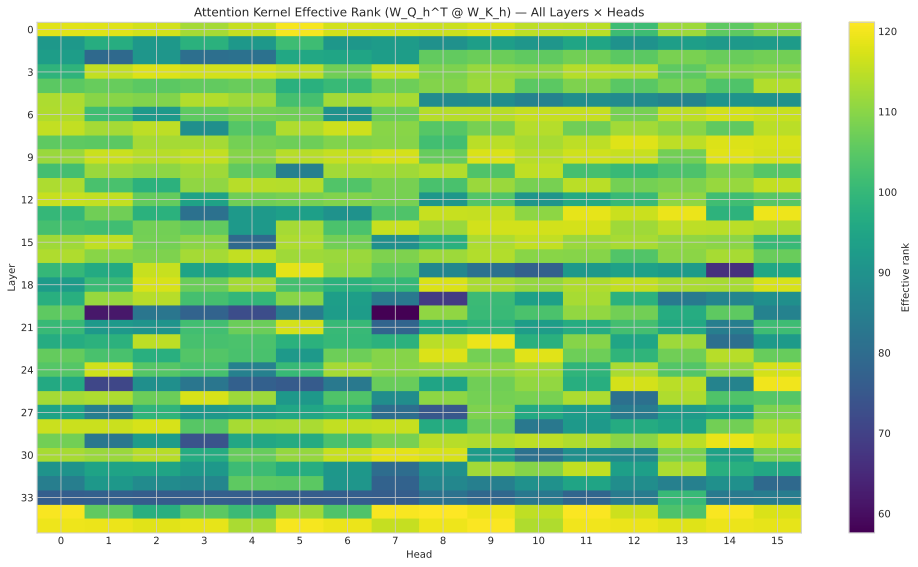

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(attn_eff_ranks, aspect="auto", cmap="viridis", interpolation="nearest")
ax.set_xlabel("Head")
ax.set_ylabel("Layer")
ax.set_title("Attention Kernel Effective Rank (W_Q_h^T @ W_K_h) — All Layers × Heads")
ax.set_xticks(range(h))
ax.set_yticks(range(0, L, max(1, L // 12)))
cbar = fig.colorbar(im, ax=ax, label="Effective rank")
plt.tight_layout()

# Summary stats
print(f"Attention kernel effective rank heatmap: shape {attn_eff_ranks.shape}")
print(f"  Global: min={attn_eff_ranks.min():.1f}, max={attn_eff_ranks.max():.1f}, "
      f"mean={attn_eff_ranks.mean():.1f}, std={attn_eff_ranks.std():.1f}")

# Identify consistently low-rank heads (potential structured/positional heads)
head_means = attn_eff_ranks.mean(axis=0)
head_stds = attn_eff_ranks.std(axis=0)
low_rank_threshold = np.percentile(head_means, 25)
high_rank_threshold = np.percentile(head_means, 75)

print(f"\n  Per-head mean eff rank (across layers):")
for hi in range(h):
    tag = ""
    if head_means[hi] <= low_rank_threshold:
        tag = " ← LOW-RANK (structured/relational?)"
    elif head_means[hi] >= high_rank_threshold:
        tag = " ← HIGH-RANK (soft lookup?)"
    print(f"    Head {hi:2d}: mean={head_means[hi]:.1f}, std={head_stds[hi]:.1f}{tag}")

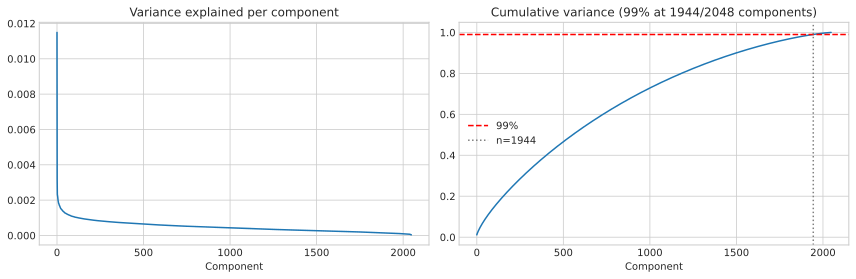

In [ ]:
S = torch.linalg.svdvals(W_down.float().cpu())
var_explained = S**2 / (S**2).sum()
cumvar = var_explained.cumsum(0).numpy()

n99 = int((cumvar < 0.99).sum()) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(var_explained.numpy())
ax1.set_title('Variance explained per component')
ax1.set_xlabel('Component')

ax2.plot(cumvar)
ax2.axhline(0.99, color='r', linestyle='--', label='99%')
ax2.axvline(n99, color='gray', linestyle=':', label=f'n={n99}')
ax2.set_title(f'Cumulative variance (99% at {n99}/{len(S)} components)')
ax2.set_xlabel('Component')
ax2.legend()
plt.tight_layout()

In [ ]:
from multiprocessing import Pool

from tqdm.auto import tqdm


def effective_rank(W):
    """Entropy-based effective rank: r_eff = exp(H(sigma_hat))."""
    S = torch.linalg.svdvals(W.float().cpu())
    sigma_hat = S / S.sum()
    # Filter zeros to avoid log(0)
    sigma_hat = sigma_hat[sigma_hat > 0]
    H = -(sigma_hat * sigma_hat.log()).sum().item()
    return np.exp(H)

WEIGHT_SPECS = [
    ("W_Q",    "q_proj",    (d, d)),
    ("W_K",    "k_proj",    ((d // h) * GQA, d)),
    ("W_V",    "v_proj",    ((d // h) * GQA, d)),
    ("W_O",    "o_proj",    (d, d)),
    ("W_gate", "gate_proj", (d_ff, d)),
    ("W_up",   "up_proj",   (d_ff, d)),
    ("W_down", "down_proj", (d, d_ff)),
]

def process_layer(layer_idx):
    layer = model.model.layers[layer_idx]
    results = []
    for weight_name, attr_name, shape in WEIGHT_SPECS:
        # Navigate to the right submodule
        if attr_name in ("q_proj", "k_proj", "v_proj", "o_proj"):
            W = getattr(layer.self_attn, attr_name).weight.data
        else:
            W = getattr(layer.mlp, attr_name).weight.data
        results.append({
            "layer_idx": layer_idx,
            "weight_type": weight_name,
            "shape": f"{shape[0]}x{shape[1]}",
            "eff_rank": effective_rank(W),
        })
    return results

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

all_results = []
BATCH = 8  # layers at a time

for batch_start in tqdm(range(0, L, BATCH), desc="Batches"):
    batch_end = min(batch_start + BATCH, L)
    
    # Load one batch of layers to CPU
    cpu_weights = {}
    for l in range(batch_start, batch_end):
        layer = model.model.layers[l]
        for wn, an, sh in WEIGHT_SPECS:
            mod = layer.self_attn if an in ("q_proj", "k_proj", "v_proj", "o_proj") else layer.mlp
            cpu_weights[(l, wn)] = getattr(mod, an).weight.data.float().cpu()

    # Parallel SVD on this batch only
    def compute_rank(layer_idx, weight_name, shape):
        W = cpu_weights[(layer_idx, weight_name)]
        return {"layer_idx": layer_idx, "weight_type": weight_name,
                "shape": f"{shape[0]}x{shape[1]}", "eff_rank": effective_rank(W)}

    with ThreadPoolExecutor(max_workers=8) as pool:
        futures = {
            pool.submit(compute_rank, l, wn, sh): (l, wn)
            for l in range(batch_start, batch_end)
            for wn, an, sh in WEIGHT_SPECS
        }
        for f in tqdm(as_completed(futures), total=len(futures), desc="Computing effective ranks..."):
            all_results.append(f.result())

    del cpu_weights

df = pd.DataFrame(all_results)
display(all_results)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Computing effective ranks...:   0%|          | 0/56 [00:00<?, ?it/s]

Computing effective ranks...:   0%|          | 0/56 [00:00<?, ?it/s]

Computing effective ranks...:   0%|          | 0/56 [00:00<?, ?it/s]

Computing effective ranks...:   0%|          | 0/56 [00:00<?, ?it/s]

Computing effective ranks...:   0%|          | 0/28 [00:00<?, ?it/s]

[{'layer_idx': 0,
  'weight_type': 'W_V',
  'shape': '256x2048',
  'eff_rank': np.float64(251.523012126592)},
 {'layer_idx': 0,
  'weight_type': 'W_K',
  'shape': '256x2048',
  'eff_rank': np.float64(240.49800444663148)},
 {'layer_idx': 1,
  'weight_type': 'W_K',
  'shape': '256x2048',
  'eff_rank': np.float64(213.47631024280147)},
 {'layer_idx': 1,
  'weight_type': 'W_V',
  'shape': '256x2048',
  'eff_rank': np.float64(249.58349548155346)},
 {'layer_idx': 0,
  'weight_type': 'W_O',
  'shape': '2048x2048',
  'eff_rank': np.float64(1706.0678633830862)},
 {'layer_idx': 0,
  'weight_type': 'W_Q',
  'shape': '2048x2048',
  'eff_rank': np.float64(1483.1956610494906)},
 {'layer_idx': 1,
  'weight_type': 'W_O',
  'shape': '2048x2048',
  'eff_rank': np.float64(1512.364697131686)},
 {'layer_idx': 1,
  'weight_type': 'W_Q',
  'shape': '2048x2048',
  'eff_rank': np.float64(1299.0466263160733)},
 {'layer_idx': 2,
  'weight_type': 'W_K',
  'shape': '256x2048',
  'eff_rank': np.float64(217.268111086

In [ ]:
import os
from pathlib import Path

model_name_fmtd = model.config.name_or_path.replace("/", "_")  # "Qwen_Qwen2.5-3B"
file_name = f"{model_name_fmtd}_Layer_Weight_Eff_Ranks.csv"

OUTPUT_DIR = Path("output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
output_path = OUTPUT_DIR / file_name

df.to_csv(output_path, index=False)
print(f"{model.config.name_or_path} [{model.config.name_or_path}] effective ranks saved to: {output_path}")

Qwen/Qwen2.5-3B [Qwen/Qwen2.5-3B] effective ranks saved to: output/Qwen_Qwen2.5-3B_Layer_Weight_Eff_Ranks.csv


In [ ]:
df = pd.read_csv(output_path)
df

,layer_idx,weight_type,shape,eff_rank
0,0,W_V,256x2048,251.523012
1,0,W_K,256x2048,240.498004
2,1,W_K,256x2048,213.476310
3,1,W_V,256x2048,249.583495
4,0,W_O,2048x2048,1706.067863
...,...,...,...,...
247,35,W_up,11008x2048,1968.729256
248,32,W_down,2048x11008,1937.016923
249,33,W_down,2048x11008,1961.330719
250,34,W_down,2048x11008,1963.826578



EFFECTIVE RANK STATISTICS BY WEIGHT TYPE

| Weight Type   | Shape      |   Count |     Min |     Max |    Mean |   Median |    Std |   Range |   First |    Last |   Variance |     CV |
|:--------------|:-----------|--------:|--------:|--------:|--------:|---------:|-------:|--------:|--------:|--------:|-----------:|-------:|
| W_V           | 256x2048   |      36 |  230.14 |  254.17 |  249.3  |   250.39 |   4.9  |   24.03 |  251.52 |  252.42 |      24.03 | 0.0197 |
| W_K           | 256x2048   |      36 |  169.7  |  240.5  |  221.96 |   224.36 |  13.49 |   70.8  |  240.5  |  238.27 |     181.95 | 0.0608 |
| W_O           | 2048x2048  |      36 | 1349.34 | 1706.07 | 1452.92 |  1444.53 |  73.25 |  356.72 | 1706.07 | 1502.29 |    5364.94 | 0.0504 |
| W_Q           | 2048x2048  |      36 | 1132.96 | 1521.81 | 1376.42 |  1370.2  |  85.35 |  388.85 | 1483.2  | 1521.81 |    7284.53 | 0.062  |
| W_gate        | 11008x2048 |      36 | 1176    | 1957.72 | 1891    |  1933.14 | 141.59 |  781.73 

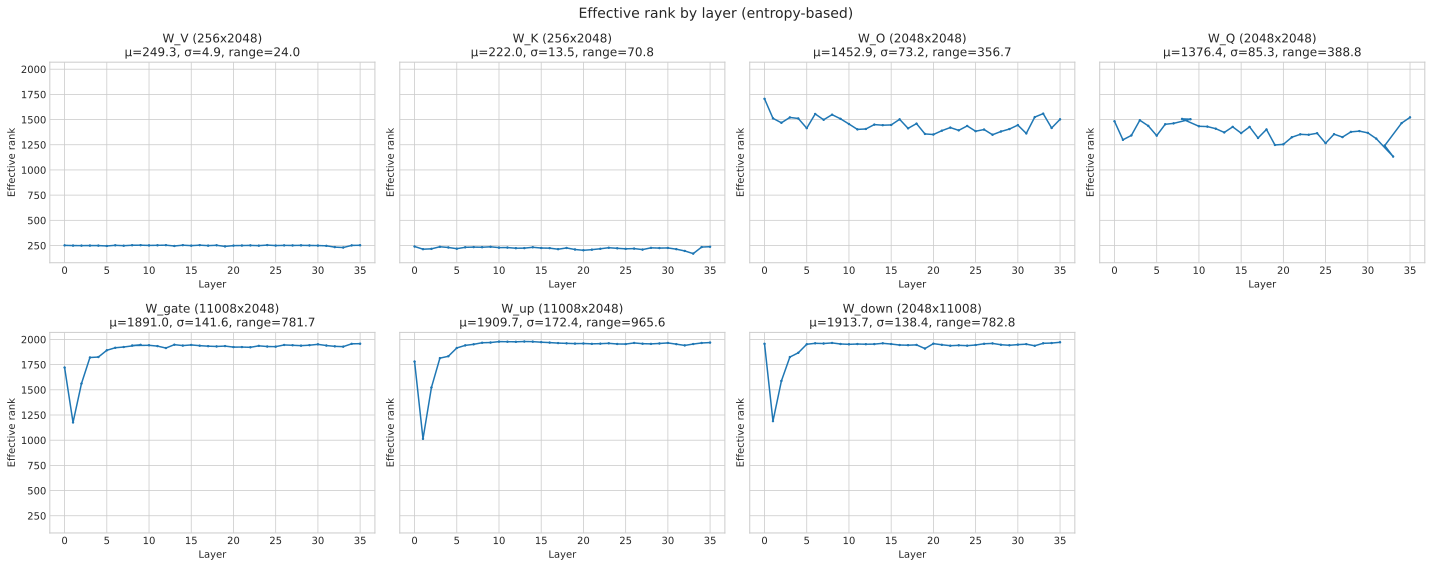

In [ ]:
weight_types = df["weight_type"].unique()
n_types = len(weight_types)

# Diagnostic statistics for each weight type
stats_data = []
for wt in weight_types:
    sub = df[df["weight_type"] == wt]
    ranks = sub["eff_rank"].values
    shape_str = sub["shape"].iloc[0]
    
    stats_data.append({
        "Weight Type": wt,
        "Shape": shape_str,
        "Count": len(ranks),
        "Min": f"{ranks.min():.2f}",
        "Max": f"{ranks.max():.2f}",
        "Mean": f"{ranks.mean():.2f}",
        "Median": f"{np.median(ranks):.2f}",
        "Std": f"{ranks.std():.2f}",
        "Range": f"{ranks.max() - ranks.min():.2f}",
        "First": f"{ranks[0]:.2f}",
        "Last": f"{ranks[-1]:.2f}",
        "Variance": f"{ranks.var():.2f}",
        "CV": f"{ranks.std() / ranks.mean():.4f}"
    })

stats_df = pd.DataFrame(stats_data)
print("\n" + "="*80)
print("EFFECTIVE RANK STATISTICS BY WEIGHT TYPE")
print("="*80 + "\n")
print(stats_df.to_markdown(index=False))
print("\n" + "="*80 + "\n")

# Plot effective ranks by layer
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=True)
axes = axes.flatten()

for i, wt in enumerate(weight_types):
    ax = axes[i]
    sub = df[df["weight_type"] == wt]
    shape_str = sub["shape"].iloc[0]
    ranks = sub["eff_rank"].values
    
    ax.plot(sub["layer_idx"], sub["eff_rank"], marker=".", markersize=3)
    ax.set_title(f"{wt} ({shape_str})\nμ={ranks.mean():.1f}, σ={ranks.std():.1f}, range={ranks.max()-ranks.min():.1f}")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Effective rank")

# Hide unused subplot
for j in range(n_types, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Effective rank by layer (entropy-based)", fontsize=14)
plt.tight_layout()

In [ ]:
# Split layers into thirds: early (encode), middle (compute), late (decode)
third = L // 3
phases = {
    f"Early (0-{third-1})": df[df["layer_idx"] < third],
    f"Middle ({third}-{2*third-1})": df[(df["layer_idx"] >= third) & (df["layer_idx"] < 2*third)],
    f"Late ({2*third}-{L-1})": df[df["layer_idx"] >= 2*third],
}

# Per-phase, per-weight-type summary
for phase_name, phase_df in phases.items():
    summary = (
        phase_df.groupby("weight_type")["eff_rank"]
        .agg(["mean", "std", "min", "max", "median"])
    )
    summary["range"] = summary["max"] - summary["min"]
    summary["cv"] = summary["std"] / summary["mean"]
    print(f"\n{'='*60}")
    print(f"  {phase_name}")
    print(f"{'='*60}")
    print(summary.to_string())

# Aggregate: does middle have lower effective rank (more structured)?
print(f"\n{'='*60}")
print("  AGGREGATE: mean eff_rank by phase")
print(f"{'='*60}")
for phase_name, phase_df in phases.items():
    mean_rank = phase_df["eff_rank"].mean()
    std_rank = phase_df["eff_rank"].std()
    print(f"  {phase_name}: {mean_rank:.2f} ± {std_rank:.2f}")

# Per-weight-type trend: does each weight show encode>compute<decode pattern?
print(f"\n{'='*60}")
print("  PER-WEIGHT PHASE MEANS (looking for U-shape: high→low→high)")
print(f"{'='*60}")
phase_keys = list(phases.keys())
for wt in weight_types:
    vals = [phases[p][phases[p]["weight_type"] == wt]["eff_rank"].mean() for p in phase_keys]
    trend = "U-SHAPE ✓" if vals[1] < vals[0] and vals[1] < vals[2] else \
            "MONOTONE ↓" if vals[0] > vals[1] > vals[2] else \
            "MONOTONE ↑" if vals[0] < vals[1] < vals[2] else \
            "OTHER"
    print(f"  {wt:8s}: early={vals[0]:.1f}  mid={vals[1]:.1f}  late={vals[2]:.1f}  → {trend}")

# Gradient of effective rank across layers (is there a phase transition?)
print(f"\n{'='*60}")
print("  LAYER-OVER-LAYER GRADIENT (looking for sharp transitions)")
print(f"{'='*60}")
for wt in weight_types:
    sub = df[df["weight_type"] == wt].sort_values("layer_idx")
    ranks = sub["eff_rank"].values
    diffs = np.diff(ranks)
    max_drop_idx = int(np.argmin(diffs))
    max_jump_idx = int(np.argmax(diffs))
    print(f"  {wt:8s}: max drop at layer {max_drop_idx}→{max_drop_idx+1} ({diffs[max_drop_idx]:+.1f}), "
          f"max jump at layer {max_jump_idx}→{max_jump_idx+1} ({diffs[max_jump_idx]:+.1f})")


  Early (0-11)
                    mean         std          min          max       median       range        cv
weight_type                                                                                      
W_K           229.525890    8.610338   213.476310   240.498004   231.522906   27.021694  0.037514
W_O          1508.430811   78.447259  1402.430586  1706.067863  1509.173979  303.637278  0.052006
W_Q          1432.165812   69.076171  1299.046626  1506.851470  1445.316037  207.804844  0.048232
W_V           250.407879    2.123837   245.780152   253.277040   250.385977    7.496888  0.008482
W_down       1843.660716  233.117201  1188.707331  1965.063986  1953.045112  776.356655  0.126443
W_gate       1799.958902  227.607068  1175.995139  1946.594673  1904.595614  770.599534  0.126451
W_up         1805.240214  281.587708  1013.536270  1978.214768  1927.958775  964.678498  0.155984

  Middle (12-23)
                    mean        std          min          max       median       ran

## Export all outputs to markdown

In [ ]:
def generate_markdown_report():
    """Generate a comprehensive markdown report of all notebook outputs."""
    lines = []
    w = lines.append

    w(f"# Transformer Weight Analysis: {model.config.name_or_path}")
    w("")
    w("## Model Configuration")
    w("")
    w("| Parameter | Value |")
    w("|-----------|-------|")
    w(f"| Layers (L) | {L} |")
    w(f"| Hidden size (d) | {d} |")
    w(f"| FFN intermediate (d_ff) | {d_ff} |")
    w(f"| Attention heads (h) | {h} |")
    w(f"| GQA heads | {GQA} |")
    w(f"| Vocab size (V) | {V} |")
    w(f"| Head dim (d_head) | {d // h} |")
    w(f"| KV dim (d_kv) | {(d // h) * GQA} |")
    w("")

    # --- Attention kernel analysis ---
    w(f"## Attention Kernel Analysis (Layer {layer_idx}, Head {head_idx})")
    w("")
    w(f"The attention kernel W_Q_h^T @ W_K_h maps input space (d={d}) to itself, "
      f"revealing what directions each head attends to.")
    w("")
    w("| Metric | Value |")
    w("|--------|-------|")
    w(f"| Kernel shape | {attn_kernel.shape[0]} x {attn_kernel.shape[1]} |")
    w(f"| Asymmetry ‖A - Aᵀ‖/‖A‖ | {symmetry_check:.4f} |")
    w(f"| Complex eigenvalues | {n_complex}/{len(eigvals_mag)} ({100*n_complex/len(eigvals_mag):.1f}%) |")
    w(f"| Top {d_head} eigenvalues energy | {100*top_k_energy:.1f}% |")
    eff_rank_val = np.exp(-np.sum(eigvals_mag/eigvals_mag.sum() * np.log(eigvals_mag/eigvals_mag.sum() + 1e-12)))
    w(f"| Effective rank (entropy) | {eff_rank_val:.1f} |")
    w(f"| 99% spectral energy at | {n99_eig}/{d} components |")
    w("")

    w("### Top 20 Eigenvalues")
    w("")
    w("| Rank | Real | Imaginary | Magnitude |")
    w("|------|------|-----------|-----------|")
    for i in range(min(20, len(eigvals_mag))):
        w(f"| {i} | {eigvals_real[i]:+.6f} | {eigvals_imag[i]:+.6f} | {eigvals_mag[i]:.6f} |")
    w("")

    w("### Eigenvalue Magnitude Spectrum")
    w("")
    nonzero_mask = eigvals_mag > 1e-8
    n_nonzero = int(nonzero_mask.sum())
    nonzero_mags = eigvals_mag[nonzero_mask]
    w(f"Of {len(eigvals_mag)} total eigenvalues, **{n_nonzero} are non-zero** "
      f"({len(eigvals_mag) - n_nonzero} are effectively zero). "
      f"The kernel is highly low-rank.")
    w("")
    w("Distribution of the **non-zero** eigenvalue magnitudes:")
    w("")
    pcts = [0, 5, 10, 25, 50, 75, 90, 95, 100]
    pct_vals = np.percentile(nonzero_mags, pcts)
    w("| Percentile | Magnitude |")
    w("|------------|-----------|")
    for p, v in zip(pcts, pct_vals):
        w(f"| {p}% | {v:.6f} |")
    w("")

    w("### Complex Plane Distribution")
    w("")
    w(f"- Real part range: [{eigvals_real.min():.4f}, {eigvals_real.max():.4f}]")
    w(f"- Imaginary part range: [{eigvals_imag.min():.4f}, {eigvals_imag.max():.4f}]")
    w(f"- {n_complex} eigenvalues have non-trivial imaginary components (|imag| > 1e-6)")
    purely_real = len(eigvals_mag) - n_complex
    w(f"- {purely_real} eigenvalues are essentially real")
    n_positive = int((eigvals_real > 0).sum())
    n_negative = int((eigvals_real < 0).sum())
    w(f"- {n_positive} have positive real part, {n_negative} have negative real part")
    w("")

    w("### Cumulative Spectral Energy")
    w("")
    cum_energy_local = np.cumsum(eigvals_mag**2) / (eigvals_mag**2).sum()
    milestones = [0.5, 0.75, 0.9, 0.95, 0.99]
    w(f"| Energy threshold | Components needed | % of total ({d}) |")
    w("|-----------------|-------------------|-----------------|")
    for m in milestones:
        n_needed = int((cum_energy_local < m).sum()) + 1
        w(f"| {100*m:.0f}% | {n_needed} | {100*n_needed/d:.1f}% |")
    w("")

    # --- Attention kernel heatmap ---
    w("## Attention Kernel Effective Rank: All Layers x All Heads")
    w("")
    w(f"Heatmap of effective rank of W_Q_h^T @ W_K_h for each of {L} layers x {h} heads. "
      f"Low-rank heads perform structured relational operations (positional, syntactic). "
      f"High-rank heads perform soft lookup.")
    w("")
    w(f"| Metric | Value |")
    w(f"|--------|-------|")
    w(f"| Global min | {attn_eff_ranks.min():.1f} |")
    w(f"| Global max | {attn_eff_ranks.max():.1f} |")
    w(f"| Global mean | {attn_eff_ranks.mean():.1f} |")
    w(f"| Global std | {attn_eff_ranks.std():.1f} |")
    w("")

    w("### Per-Head Summary (mean across layers)")
    w("")
    w("| Head | Mean | Std | Min | Max | Category |")
    w("|------|------|-----|-----|-----|----------|")
    for hi in range(h):
        col = attn_eff_ranks[:, hi]
        cat = "LOW-RANK" if head_means[hi] <= low_rank_threshold else \
              "HIGH-RANK" if head_means[hi] >= high_rank_threshold else "MID"
        w(f"| {hi} | {col.mean():.1f} | {col.std():.1f} | {col.min():.1f} | {col.max():.1f} | {cat} |")
    w("")

    w("### Per-Layer Summary (mean across heads)")
    w("")
    w("| Layer | Mean | Std | Min | Max |")
    w("|-------|------|-----|-----|-----|")
    for li in range(L):
        row = attn_eff_ranks[li, :]
        w(f"| {li} | {row.mean():.1f} | {row.std():.1f} | {row.min():.1f} | {row.max():.1f} |")
    w("")

    w("### Full Heatmap Data (Layer x Head)")
    w("")
    heatmap_df = pd.DataFrame(attn_eff_ranks, columns=[f"H{hi}" for hi in range(h)])
    heatmap_df.index.name = "Layer"
    w(heatmap_df.round(1).to_markdown())
    w("")

    # --- W_down SVD ---
    w(f"## W_down SVD Analysis (Layer {layer_idx})")
    w("")
    S_local = torch.linalg.svdvals(W_down.float().cpu())
    var_exp = (S_local**2 / (S_local**2).sum()).numpy()
    cumvar_local = np.cumsum(var_exp)
    n99_local = int((cumvar_local < 0.99).sum()) + 1
    w(f"- Shape: {W_down.shape[0]} x {W_down.shape[1]}")
    w(f"- 99% variance captured by {n99_local}/{len(S_local)} singular values")
    w(f"- Top singular value: {S_local[0].item():.4f}")
    w(f"- Smallest singular value: {S_local[-1].item():.6f}")
    w(f"- Condition number: {S_local[0].item() / S_local[-1].item():.1f}")
    w("")
    w("| Variance threshold | Components needed |")
    w("|-------------------|-------------------|")
    for m in milestones:
        n_needed = int((cumvar_local < m).sum()) + 1
        w(f"| {100*m:.0f}% | {n_needed} |")
    w("")

    # --- Effective rank table ---
    w("## Effective Rank by Layer and Weight Type")
    w("")
    w("Effective rank = exp(entropy of normalized singular values). "
      "Higher = more spread out spectrum, lower = more low-rank.")
    w("")
    w(stats_df.to_markdown(index=False))
    w("")

    # --- Per-layer effective rank data ---
    w("### Effective Rank Per Layer")
    w("")
    pivot = df.pivot(index="layer_idx", columns="weight_type", values="eff_rank")
    w(pivot.to_markdown())
    w("")

    # --- Phase analysis ---
    w("## Phase Analysis: Encode → Compute → Decode")
    w("")
    w(f"Layers split into thirds: early (0–{third-1}), middle ({third}–{2*third-1}), late ({2*third}–{L-1}).")
    w("")

    w("### Aggregate Mean Effective Rank by Phase")
    w("")
    w("| Phase | Mean eff_rank | Std |")
    w("|-------|--------------|-----|")
    for phase_name, phase_df in phases.items():
        mean_rank = phase_df["eff_rank"].mean()
        std_rank = phase_df["eff_rank"].std()
        w(f"| {phase_name} | {mean_rank:.2f} | {std_rank:.2f} |")
    w("")

    w("### Per-Phase, Per-Weight Statistics")
    w("")
    for phase_name, phase_df in phases.items():
        w(f"#### {phase_name}")
        w("")
        summary = (
            phase_df.groupby("weight_type")["eff_rank"]
            .agg(["mean", "std", "min", "max", "median"])
        )
        summary["range"] = summary["max"] - summary["min"]
        summary["cv"] = summary["std"] / summary["mean"]
        w(summary.to_markdown())
        w("")

    w("### Per-Weight Phase Trend")
    w("")
    w("Looking for U-shape pattern (high → low → high) which would indicate "
      "middle layers are more structured/low-rank.")
    w("")
    w("| Weight | Early | Middle | Late | Trend |")
    w("|--------|-------|--------|------|-------|")
    phase_keys = list(phases.keys())
    for wt in weight_types:
        vals = [phases[p][phases[p]["weight_type"] == wt]["eff_rank"].mean() for p in phase_keys]
        trend = "U-SHAPE" if vals[1] < vals[0] and vals[1] < vals[2] else \
                "MONOTONE DOWN" if vals[0] > vals[1] > vals[2] else \
                "MONOTONE UP" if vals[0] < vals[1] < vals[2] else \
                "OTHER"
        w(f"| {wt} | {vals[0]:.1f} | {vals[1]:.1f} | {vals[2]:.1f} | {trend} |")
    w("")

    w("### Layer-over-Layer Gradient (Sharp Transitions)")
    w("")
    w("| Weight | Max Drop (layers) | Drop Δ | Max Jump (layers) | Jump Δ |")
    w("|--------|-------------------|--------|-------------------|--------|")
    for wt in weight_types:
        sub = df[df["weight_type"] == wt].sort_values("layer_idx")
        ranks = sub["eff_rank"].values
        diffs = np.diff(ranks)
        max_drop_idx = int(np.argmin(diffs))
        max_jump_idx = int(np.argmax(diffs))
        w(f"| {wt} | {max_drop_idx}→{max_drop_idx+1} | {diffs[max_drop_idx]:+.1f} | "
          f"{max_jump_idx}→{max_jump_idx+1} | {diffs[max_jump_idx]:+.1f} |")
    w("")

    return "\n".join(lines)


md_content = generate_markdown_report()
md_path = OUTPUT_DIR / "one_output.md"
md_path.write_text(md_content)
print(f"Markdown report written to: {md_path}")

Markdown report written to: output/one_output.md
